# Differential Privacy: Insurance Dataset

## 1) Introduction: Privacy–Utility Trade-off
This notebook studies the privacy–utility trade-off for a binary classifier predicting **smoker** status from the insurance dataset. We compare baseline models (SVM and decision tree) with feature-level differential privacy (DP) noise mechanisms and a DP-SGD neural network. **ROC-AUC** is the primary metric used throughout.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

from dp.constants import RANDOM_STATE
from dp.dpsgd import opacus_available
from dp.fairness import demographic_parity_difference, equalized_odds_difference
from dp.models import build_decision_tree_model, build_svm_model
from dp.pipeline import apply_bounded_feature_noise, build_preprocessor, clip_numeric, split_dataset

np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8")

## 2) Dataset overview + class imbalance

In [2]:
repo_root = Path("..").resolve()
data_path = repo_root / "data" / "insurance.csv"

df = pd.read_csv(data_path)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


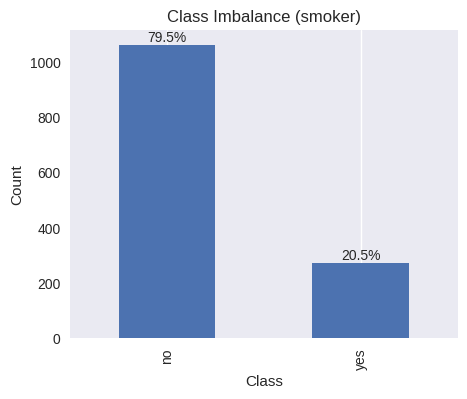

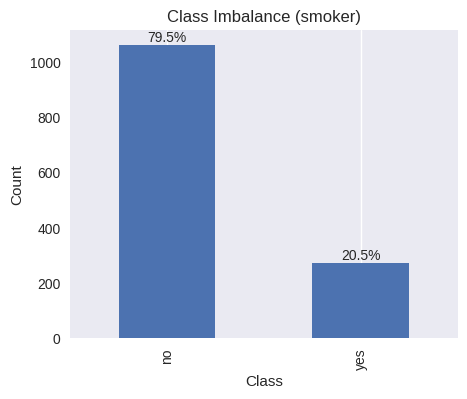

In [4]:
class_counts = df["smoker"].value_counts()
class_props = class_counts / class_counts.sum()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Class Imbalance (smoker)")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
for idx, value in enumerate(class_counts.values):
    ax.text(idx, value, f"{class_props.iloc[idx]:.1%}", ha="center", va="bottom")
ax.grid(axis="y")
fig


## 3) Baseline models (SVM, Decision Tree)
We train baseline models with standard preprocessing (scaling numeric features and one-hot encoding categorical features). ROC-AUC is computed on a held-out test set.


In [5]:
split = split_dataset(df, target="smoker")
preprocessor = build_preprocessor(split.X_train)

X_train = preprocessor.fit_transform(split.X_train)
X_test = preprocessor.transform(split.X_test)

y_train = (split.y_train == "yes").astype(int).to_numpy()
y_test = (split.y_test == "yes").astype(int).to_numpy()

models = {
    "svm": build_svm_model(),
    "decision_tree": build_decision_tree_model(),
}

baseline_rows = []
baseline_rocs = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, scores)
    baseline_rows.append({"model": name, "roc_auc": roc_auc})
    fpr, tpr, _ = roc_curve(y_test, scores)
    baseline_rocs[name] = (fpr, tpr)

baseline_results = pd.DataFrame(baseline_rows)
baseline_results


,model,roc_auc
0,svm,0.994793
1,decision_tree,0.917883


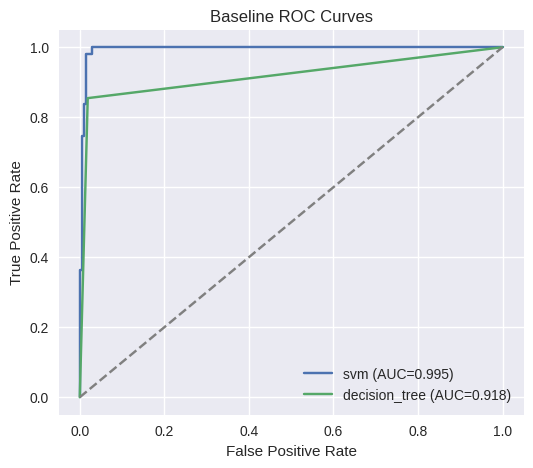

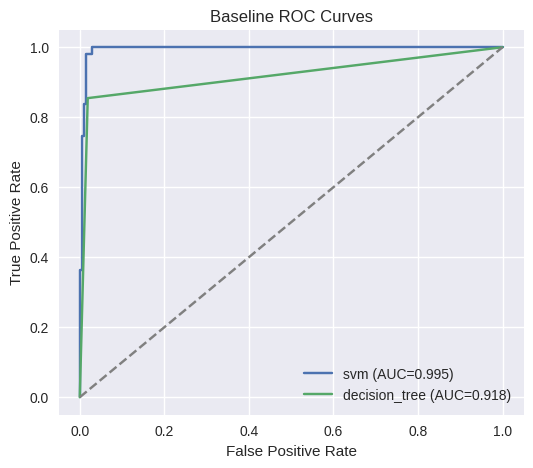

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, (fpr, tpr) in baseline_rocs.items():
    auc_val = baseline_results.loc[baseline_results["model"] == name, "roc_auc"].iloc[0]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Baseline ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True)
fig


## 4) Feature-level DP
We apply DP noise to numeric features after **clipping them to fixed, publicly known domain bounds** and rescaling each column to [0, 1]. With $d$ numeric columns rescaled this way, one record changes the full numeric row by at most $d$ in $L_1$ norm ($\sqrt{d}$ in $L_2$), so a single ε (or (ε, δ)) budget covers the **joint release of all numeric features** — no per-column composition bookkeeping is needed, and no single wide column (like `charges`) dictates the noise scale for narrow ones (like `children`).

Two details matter for the guarantee:

1. **Bounds must be data-independent.** Quantiles computed from the private data would leak information outside the DP accounting, so we use fixed bounds from the public domain of each feature.
2. **Gaussian noise is calibrated with the analytic Gaussian mechanism** (Balle & Wang, 2018), which is valid for all ε > 0; the classic σ = Δ·√(2·ln(1.25/δ))/ε bound only holds for ε ≤ 1.

We compare Laplace (ε-DP) and Gaussian ((ε, δ)-DP), then plot ROC-AUC vs ε on a log scale.

In [7]:
# Fixed, publicly known domain bounds — data-independent by construction.
PUBLIC_BOUNDS = pd.DataFrame(
    {
        "lower": {"age": 18.0, "bmi": 15.0, "children": 0.0, "charges": 0.0},
        "upper": {"age": 65.0, "bmi": 55.0, "children": 5.0, "charges": 65_000.0},
    }
)
PUBLIC_BOUNDS

,lower,upper
age,18.0,65.0
bmi,15.0,55.0
children,0.0,5.0
charges,0.0,65000.0


In [8]:
clipped_test = clip_numeric(split.X_test, PUBLIC_BOUNDS)

epsilons = np.logspace(-2, 1, 6)


def evaluate_dp_features(mechanism: str, epsilons: np.ndarray, delta: float = 1e-5) -> pd.DataFrame:
    rows = []
    for epsilon in epsilons:
        noisy_train = apply_bounded_feature_noise(
            split.X_train,
            PUBLIC_BOUNDS,
            mechanism=mechanism,
            epsilon=epsilon,
            delta=delta,
            random_state=RANDOM_STATE,
        )
        preprocessor = build_preprocessor(noisy_train)
        X_train_noisy = preprocessor.fit_transform(noisy_train)
        X_test_noisy = preprocessor.transform(clipped_test)
        for name, model in models.items():
            model.fit(X_train_noisy, y_train)
            scores = model.predict_proba(X_test_noisy)[:, 1]
            roc_auc = roc_auc_score(y_test, scores)
            rows.append({"mechanism": mechanism, "epsilon": epsilon, "model": name, "roc_auc": roc_auc})
    return pd.DataFrame(rows)


laplace_results = evaluate_dp_features("laplace", epsilons)
gaussian_results = evaluate_dp_features("gaussian", epsilons)

feature_dp_results = pd.concat([laplace_results, gaussian_results], ignore_index=True)
feature_dp_results.pivot_table(index="epsilon", columns=["mechanism", "model"], values="roc_auc").round(4)

mechanism      gaussian               laplace        
model     decision_tree     svm decision_tree     svm
epsilon                                              
0.010000         0.5000  0.4808        0.4254  0.4471
0.039811         0.5000  0.4808        0.4769  0.4472
0.158489         0.3889  0.4807        0.5000  0.4444
0.630957         0.5109  0.4798        0.5067  0.5377
2.511886         0.5585  0.5092        0.5211  0.5327
10.000000        0.5357  0.5301        0.6428  0.6715

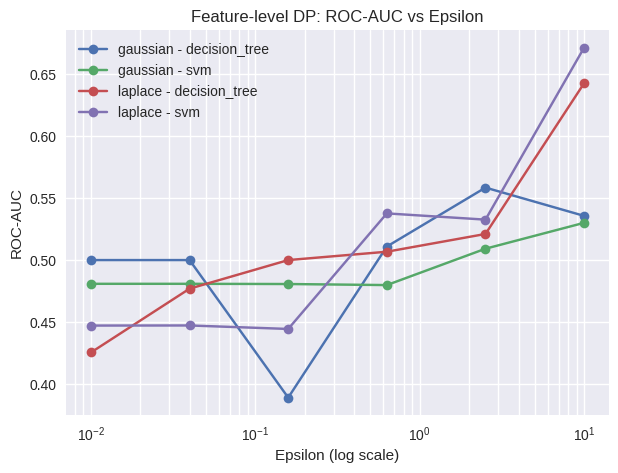

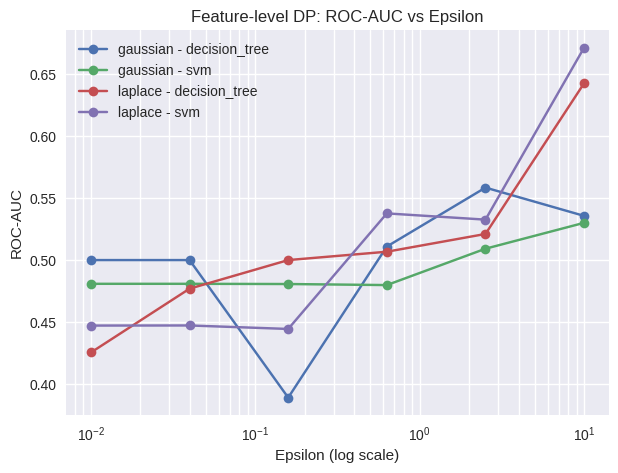

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for (mechanism, model_name), subset in feature_dp_results.groupby(["mechanism", "model"]):
    ax.plot(subset["epsilon"], subset["roc_auc"], marker="o", label=f"{mechanism} - {model_name}")
ax.set_xscale("log")
ax.set_xlabel("Epsilon (log scale)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Feature-level DP: ROC-AUC vs Epsilon")
ax.grid(True, which="both")
ax.legend()
fig


**Why performance collapses at very low ε:**
Low ε implies heavier noise, which overwhelms the signal in clipped numeric features. As the noise scale grows, discriminative patterns blur and classifiers approach random guessing (ROC-AUC ≈ 0.5). This is most pronounced for high-dimensional feature spaces where noise is injected per feature.


## 5) Excluded mechanisms
We exclude mechanisms such as **randomized response** (suited for binary categorical data) and **output perturbation** of model parameters. This notebook focuses on feature-level perturbation and training-time DP (DP-SGD) to keep the experimental scope clear and directly comparable via ROC-AUC.


## 6) DP-SGD (Neural Network)
We train a small neural network with **Opacus** to provide training-time privacy. We report ROC-AUC and the **computed ε** from the privacy accountant. We also note that **threshold tuning is post-processing**, which does not consume additional privacy budget.


In [10]:
if opacus_available():
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from opacus import PrivacyEngine

    torch.manual_seed(RANDOM_STATE)

    X_full = preprocessor.fit_transform(split.X_train)
    X_eval = preprocessor.transform(split.X_test)
    y_full = torch.tensor(y_train, dtype=torch.float32)
    y_eval = torch.tensor(y_test, dtype=torch.float32)

    X_full_tensor = torch.tensor(X_full, dtype=torch.float32)
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    dataset = TensorDataset(X_full_tensor, y_full)

    def train_with_noise_multiplier(noise_multiplier: float, epochs: int = 15):
        model = nn.Sequential(
            nn.Linear(X_full_tensor.shape[1], 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
        loss_fn = nn.BCEWithLogitsLoss()
        data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

        privacy_engine = PrivacyEngine()
        model, optimizer, data_loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=data_loader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=1.0,
        )

        model.train()
        for _ in range(epochs):
            for features, labels in data_loader:
                optimizer.zero_grad()
                logits = model(features).squeeze(1)
                loss = loss_fn(logits, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(X_eval_tensor).squeeze(1)
            probs = torch.sigmoid(logits).numpy()
        roc_auc = roc_auc_score(y_test, probs)
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        return epsilon, roc_auc

    noise_multipliers = [0.5, 1.0, 1.5, 2.0]
    dp_sgd_rows = []
    for nm in noise_multipliers:
        epsilon, roc_auc = train_with_noise_multiplier(nm)
        dp_sgd_rows.append({"noise_multiplier": nm, "epsilon": epsilon, "roc_auc": roc_auc})

    dp_sgd_results = pd.DataFrame(dp_sgd_rows)
    dp_sgd_results
else:
    dp_sgd_results = pd.DataFrame(columns=["noise_multiplier", "epsilon", "roc_auc"])
    print("Opacus/torch not available; skipping DP-SGD training.")


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6508/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6508/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6508/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6508/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [11]:
dp_sgd_results.round(4)

,noise_multiplier,epsilon,roc_auc
0,0.5,32.0865,0.9932
1,1.0,6.3774,0.9927
2,1.5,3.1909,0.9926
3,2.0,2.1290,0.9940


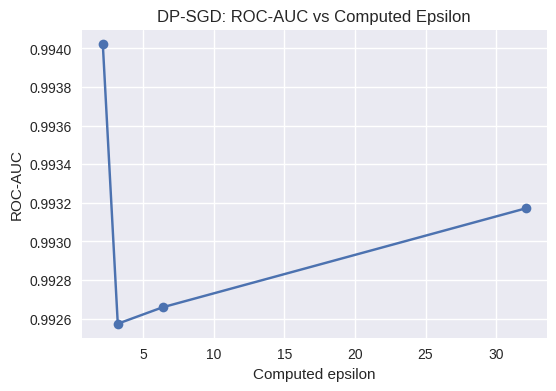

In [12]:
if not dp_sgd_results.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(dp_sgd_results["epsilon"], dp_sgd_results["roc_auc"], marker="o")
    ax.set_xlabel("Computed epsilon")
    ax.set_ylabel("ROC-AUC")
    ax.set_title("DP-SGD: ROC-AUC vs Computed Epsilon")
    ax.grid(True)
    fig


**Threshold tuning (post-processing invariance):**
Once we have model scores, choosing a decision threshold is a post-processing step. Differential privacy is closed under post-processing, so tuning thresholds (e.g., for fairness or operational constraints) does **not** consume additional privacy budget.


## 7) Fairness baseline (DP diff, EO diff)
We report demographic parity (DP) difference and equalized odds (EO) difference using **sex** as the protected attribute, computed with `dp.fairness`. The decision threshold is chosen to maximise Youden's J statistic **on the training scores** — choosing it on the test set would leak test labels into the decision rule. Because thresholding and fairness auditing are post-processing of model scores, neither consumes additional privacy budget.

In [13]:
protected = split.X_test["sex"].to_numpy()

baseline_model = build_svm_model()
baseline_model.fit(X_train, y_train)

# Threshold chosen on TRAINING scores only (no test-set leakage).
train_scores = baseline_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, train_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]

baseline_scores = baseline_model.predict_proba(X_test)[:, 1]
baseline_preds = (baseline_scores >= best_threshold).astype(int)

fairness_results = pd.DataFrame(
    {
        "metric": ["demographic_parity_diff", "equalized_odds_diff"],
        "value": [
            demographic_parity_difference(baseline_preds, protected),
            equalized_odds_difference(y_test, baseline_preds, protected),
        ],
    }
)

fairness_results

,metric,value
0,demographic_parity_diff,0.170232
1,equalized_odds_diff,0.200000


## 8) Discussion summary
- **Utility drops with stronger privacy**: As ε decreases, noise dominates feature signal and ROC-AUC trends toward chance-level.
- **Gaussian vs Laplace**: Both mechanisms follow the same trade-off pattern; Gaussian requires a δ parameter and can be tuned for similar utility.
- **DP-SGD provides training-time privacy**: When Opacus is available, the accountant yields an ε that can be compared directly to feature-level DP.
- **Fairness metrics**: DP/EO differences quantify group disparities and can be monitored alongside ROC-AUC without affecting privacy through post-processing.
